# EEG_08b — Ablation Study: Metodi di Costruzione del Grafo

Questo notebook analizza i risultati dell'esperimento EEG_08, confrontando **5 metodi di costruzione del grafo** (PCC, PLV, wPLI, Learned, Dynamic) e **3-4 architetture ChebGCN** su un task di classificazione a 4 categorie semantiche (chance level = 25%).

**Obiettivo**: capire se il metodo di costruzione del grafo influenza le performance, o se tutti i modelli collassano sulla classe maggioritaria (class collapse), e identificare qual è il trade-off velocità/accuratezza.

**Env**: `daniele_311` | **Dataset**: EEG imagined speech, 70 soggetti, 4 classi semantiche

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

# ---------------------------------------------------------------------------
# Risultati hardcoded (i CSV sono sulla VM remota)
# (method, model, val_acc, val_bacc, test_acc, test_bacc, time_s)
# ---------------------------------------------------------------------------
results = [
    ("PCC",     "ChebGCN_2L",      0.2035, 0.2527, 0.2018, 0.2490, 142.2),
    ("PCC",     "ChebGCN_3L",      0.2387, 0.2607, 0.2251, 0.2445, 303.6),
    ("PCC",     "ChebGCN_Skip",    0.3942, 0.2538, 0.3875, 0.2524, 189.8),
    ("PLV",     "ChebGCN_2L",      0.3833, 0.2557, 0.3555, 0.2437, 205.8),
    ("PLV",     "ChebGCN_3L",      0.3178, 0.2522, 0.3222, 0.2469, 197.7),
    ("PLV",     "ChebGCN_Skip",    0.4002, 0.2503, 0.3999, 0.2499, 225.5),
    ("wPLI",    "ChebGCN_2L",      0.1733, 0.2511, 0.1755, 0.2514, 171.0),
    ("wPLI",    "ChebGCN_3L",      0.3913, 0.2528, 0.3915, 0.2512, 224.1),
    ("wPLI",    "ChebGCN_Skip",    0.3482, 0.2535, 0.3463, 0.2515, 163.6),
    ("Learned", "ChebGCN_Learned", 0.1829, 0.2528, 0.1753, 0.2430, 6219.5),
    ("Dynamic", "ChebGCN_Dynamic", 0.2464, 0.2501, 0.2481, 0.2485, 7410.6),
]

df = pd.DataFrame(results, columns=["method", "model", "val_acc", "val_bacc", "test_acc", "test_bacc", "time_s"])
df["time_min"] = df["time_s"] / 60.0

CHANCE = 0.25

# Trova la root del progetto tramite .git
_here = Path(".").resolve()
project_root = _here
for p in [_here, *_here.parents]:
    if (p / ".git").exists():
        project_root = p
        break
figures_dir = project_root / "figures"
figures_dir.mkdir(exist_ok=True)

print(f"Project root: {project_root}")
print(f"Figures dir:  {figures_dir}")
print()
print(df.to_string(index=False))

Project root: /home/daniele_u/miralis-hypergraph-imagined-speech
Figures dir:  /home/daniele_u/miralis-hypergraph-imagined-speech/figures

 method           model  val_acc  val_bacc  test_acc  test_bacc  time_s   time_min
    PCC      ChebGCN_2L   0.2035    0.2527    0.2018     0.2490   142.2   2.370000
    PCC      ChebGCN_3L   0.2387    0.2607    0.2251     0.2445   303.6   5.060000
    PCC    ChebGCN_Skip   0.3942    0.2538    0.3875     0.2524   189.8   3.163333
    PLV      ChebGCN_2L   0.3833    0.2557    0.3555     0.2437   205.8   3.430000
    PLV      ChebGCN_3L   0.3178    0.2522    0.3222     0.2469   197.7   3.295000
    PLV    ChebGCN_Skip   0.4002    0.2503    0.3999     0.2499   225.5   3.758333
   wPLI      ChebGCN_2L   0.1733    0.2511    0.1755     0.2514   171.0   2.850000
   wPLI      ChebGCN_3L   0.3913    0.2528    0.3915     0.2512   224.1   3.735000
   wPLI    ChebGCN_Skip   0.3482    0.2535    0.3463     0.2515   163.6   2.726667
Learned ChebGCN_Learned   0.182

## Plot 1 — Ablation: val_bacc per Metodo × Architettura

Il grafico mostra la **balanced accuracy** (val_bacc) per ogni combinazione metodo-architettura.  
La balanced accuracy è la metrica corretta in presenza di class imbalance: un valore pari a 0.25 indica che il modello non apprende nulla (chance level su 4 classi).

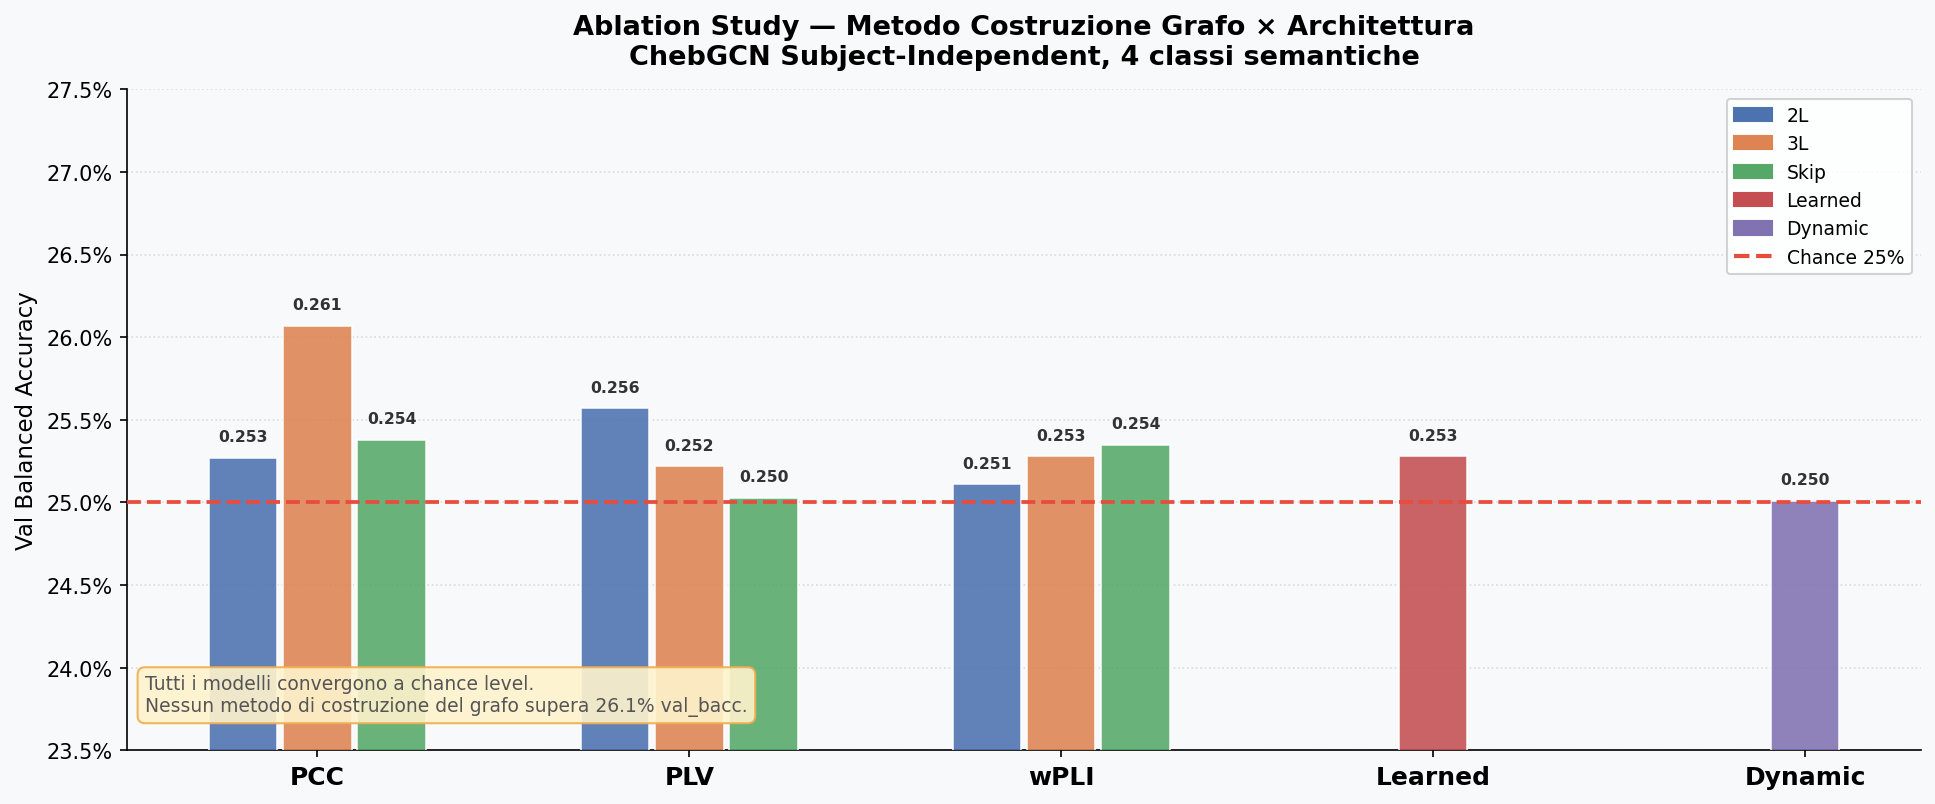

Figura caricata da: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg08_ablation_graph_methods.png


In [22]:
from IPython.display import Image, display

plot1_path = figures_dir / "eeg08_ablation_graph_methods.png"

if plot1_path.exists():
    display(Image(filename=str(plot1_path)))
    print(f"Figura caricata da: {plot1_path}")
else:
    print(f"[INFO] File non trovato localmente: {plot1_path}")
    print("Questa figura è stata generata sulla VM remota durante il training EEG_08.")
    print("Eseguire il notebook EEG_08 sulla VM per rigenerarla.")

## Plot 2 — val_acc vs val_bacc: Class Collapse

Scatter plot che mette in evidenza il fenomeno di **class collapse**: alcuni modelli raggiungono una `val_acc` elevata (fino a ~40%) ma la loro `val_bacc` rimane a ~25%, il che indica che predicono quasi sempre la classe maggioritaria anziché aver imparato a distinguere le categorie.

Una `val_bacc` > 0.25 è il vero indicatore di apprendimento.

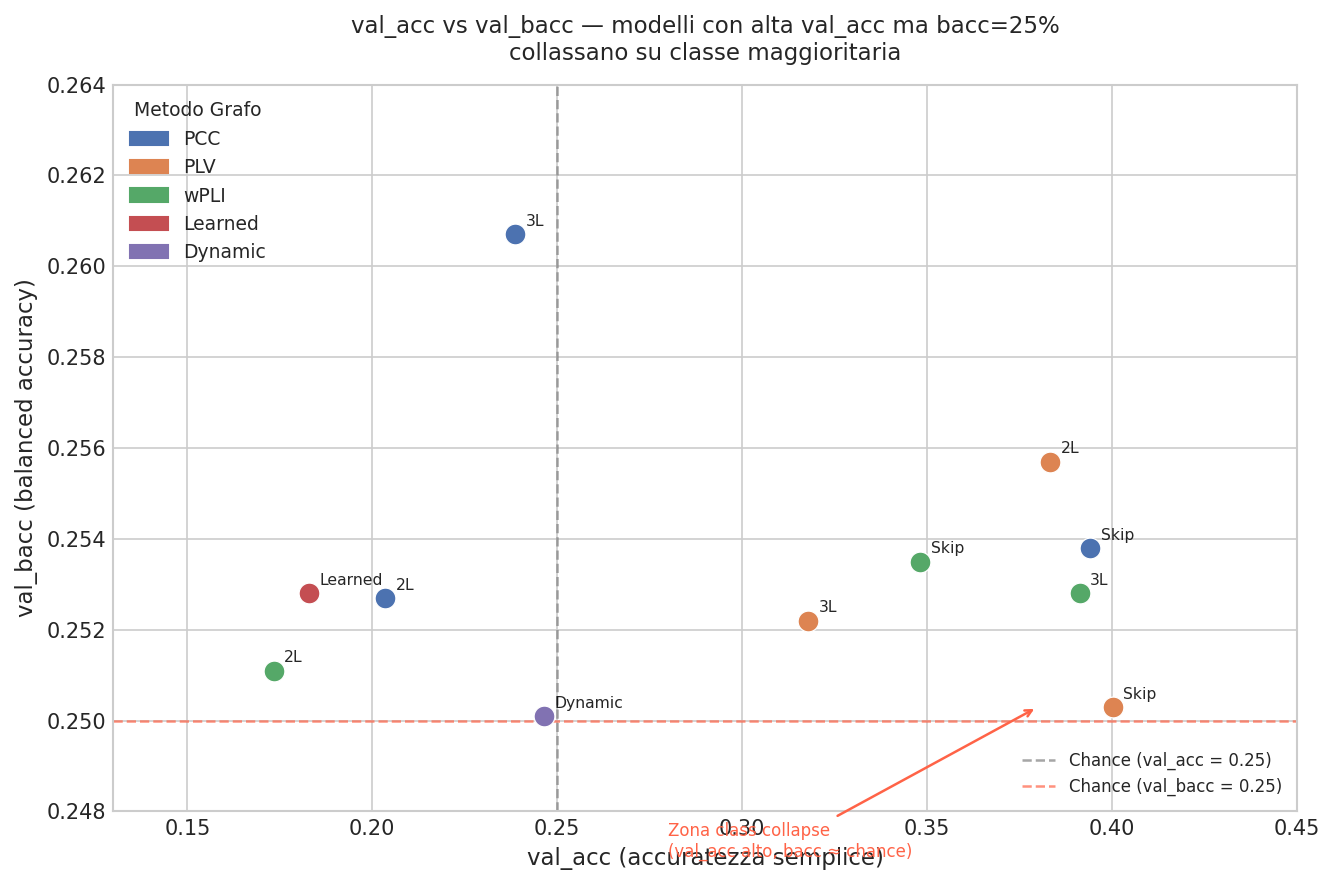

Salvato in: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg08_acc_vs_bacc.png


In [23]:
plt.style.use("seaborn-v0_8-whitegrid")

METHOD_COLORS = {
    "PCC":     "#4C72B0",
    "PLV":     "#DD8452",
    "wPLI":    "#55A868",
    "Learned": "#C44E52",
    "Dynamic": "#8172B2",
}

fig, ax = plt.subplots(figsize=(9, 6), dpi=150)

for _, row in df.iterrows():
    color = METHOD_COLORS.get(row["method"], "gray")
    ax.scatter(row["val_acc"], row["val_bacc"], color=color, s=100, zorder=5,
               edgecolors="white", linewidths=0.6)
    # Annotazione con nome modello (font piccolo)
    short_name = row["model"].replace("ChebGCN_", "")
    ax.annotate(
        short_name,
        xy=(row["val_acc"], row["val_bacc"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=7.5,
        color="black",
        alpha=0.85,
    )

# Linee di chance level
ax.axvline(CHANCE, color="gray", linestyle="--", linewidth=1.2, alpha=0.7, label="Chance (val_acc = 0.25)")
ax.axhline(CHANCE, color="tomato", linestyle="--", linewidth=1.2, alpha=0.7, label="Chance (val_bacc = 0.25)")

# Legenda metodi
legend_patches = [
    mpatches.Patch(color=c, label=m) for m, c in METHOD_COLORS.items()
]
legend1 = ax.legend(handles=legend_patches, title="Metodo Grafo", loc="upper left",
                    fontsize=9, title_fontsize=9)
ax.add_artist(legend1)
ax.legend(loc="lower right", fontsize=8)

ax.set_xlabel("val_acc (accuratezza semplice)", fontsize=11)
ax.set_ylabel("val_bacc (balanced accuracy)", fontsize=11)
ax.set_title(
    "val_acc vs val_bacc — modelli con alta val_acc ma bacc=25%\ncollassano su classe maggioritaria",
    fontsize=11, pad=12
)

# Annotazione zona collapse
ax.annotate(
    "Zona class collapse\n(val_acc alto, bacc ≈ chance)",
    xy=(0.38, 0.2503), xytext=(0.28, 0.247),
    fontsize=8, color="tomato",
    arrowprops=dict(arrowstyle="->", color="tomato", lw=1.2),
)

ax.set_xlim(0.13, 0.45)
ax.set_ylim(0.248, 0.264)

plt.tight_layout()
out_path = figures_dir / "eeg08_acc_vs_bacc.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvato in: {out_path}")

## Plot 3 — Heatmap: val_bacc per Metodo × Architettura

La heatmap mostra come la balanced accuracy vari al variare del metodo di costruzione del grafo (righe) e dell'architettura GCN (colonne). Le combinazioni inesistenti sono lasciate bianche (NaN).

Colore verde = val_bacc > 0.25 (sopra chance), rosso = sotto chance.

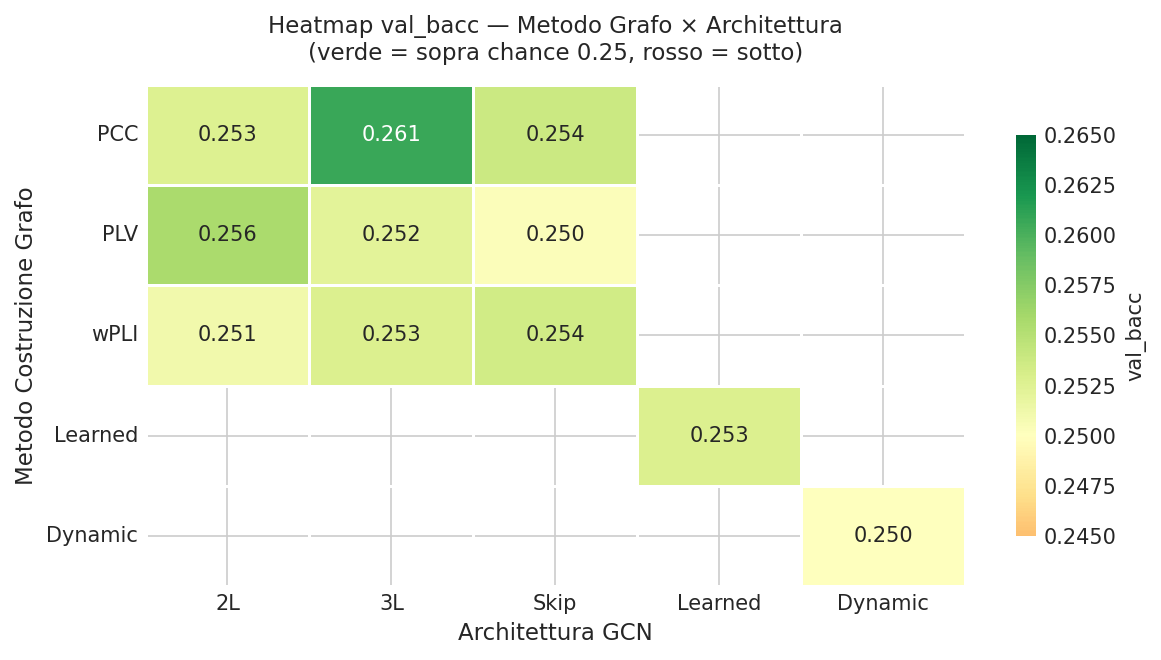

Salvato in: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg08_heatmap_bacc.png


In [24]:
# Mappa il nome del modello alla colonna corta per la heatmap
arch_map = {
    "ChebGCN_2L":      "2L",
    "ChebGCN_3L":      "3L",
    "ChebGCN_Skip":    "Skip",
    "ChebGCN_Learned": "Learned",
    "ChebGCN_Dynamic": "Dynamic",
}
df["arch"] = df["model"].map(arch_map)

METHODS = ["PCC", "PLV", "wPLI", "Learned", "Dynamic"]
ARCHS   = ["2L", "3L", "Skip", "Learned", "Dynamic"]

# Costruisci la matrice (NaN dove la combinazione non esiste)
heatmap_data = pd.DataFrame(np.nan, index=METHODS, columns=ARCHS)
for _, row in df.iterrows():
    heatmap_data.loc[row["method"], row["arch"]] = row["val_bacc"]

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=150)
sns.heatmap(
    heatmap_data,
    ax=ax,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=CHANCE,
    vmin=0.245,
    vmax=0.265,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "val_bacc", "shrink": 0.8},
    annot_kws={"size": 10},
)
ax.set_title("Heatmap val_bacc — Metodo Grafo × Architettura\n(verde = sopra chance 0.25, rosso = sotto)",
             fontsize=11, pad=12)
ax.set_xlabel("Architettura GCN", fontsize=11)
ax.set_ylabel("Metodo Costruzione Grafo", fontsize=11)
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10, rotation=0)

plt.tight_layout()
out_path = figures_dir / "eeg08_heatmap_bacc.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvato in: {out_path}")

## Plot 4 — Tempo di Training per Metodo

I metodi **Learned** (~103 min) e **Dynamic** (~123 min) sono circa **50× più lenti** dei metodi basati su connettività funzionale (PCC/PLV/wPLI: 2-5 min), senza alcun guadagno in balanced accuracy.

Questo rende i grafi pre-calcolati (PCC/PLV/wPLI) la scelta più efficiente per il prossimo step.

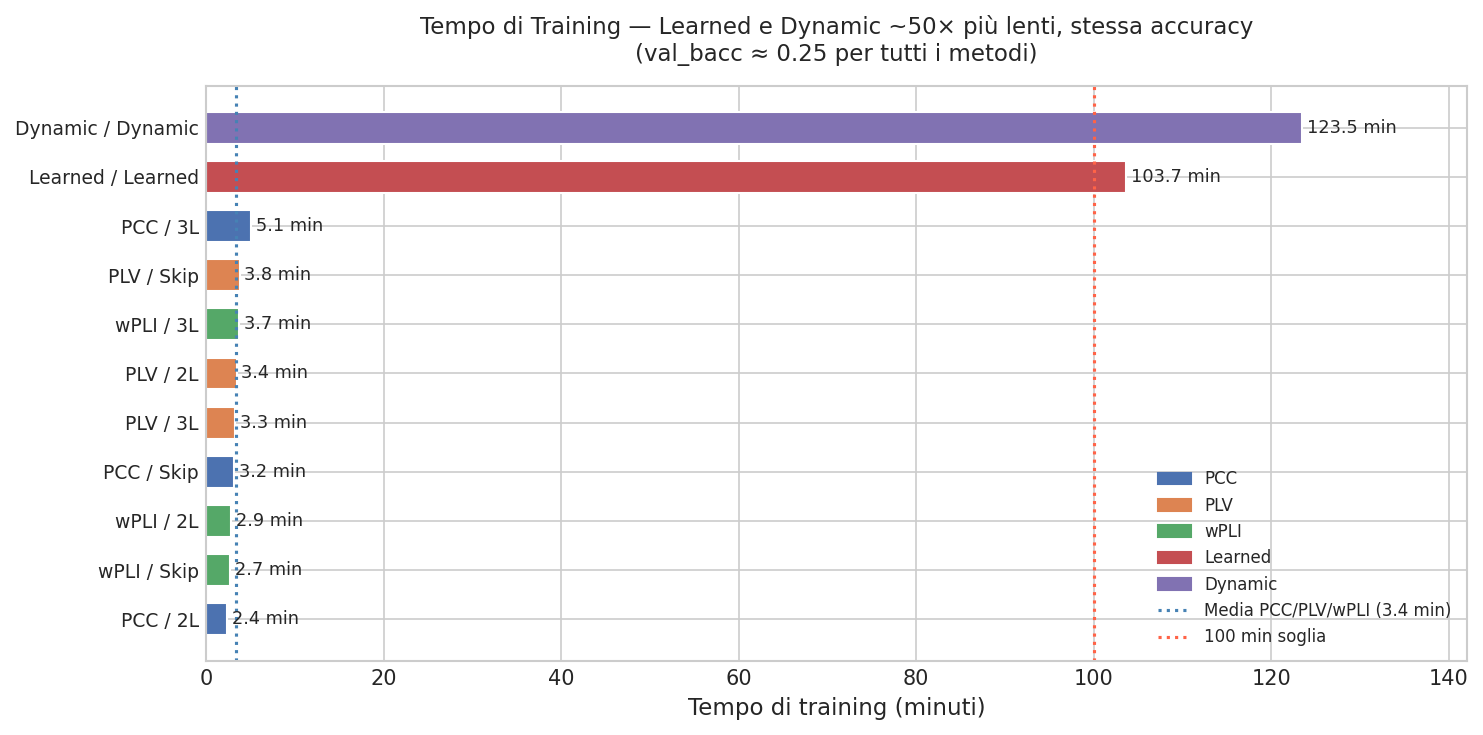

Salvato in: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg08_training_time.png


In [25]:
df_time = df.sort_values("time_min", ascending=True).copy()
labels = [f"{row['method']} / {row['arch']}" for _, row in df_time.iterrows()]
times  = df_time["time_min"].values
colors = [METHOD_COLORS.get(m, "gray") for m in df_time["method"]]

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
bars = ax.barh(labels, times, color=colors, edgecolor="white", height=0.65)

# Annotazioni sul valore
for bar, t in zip(bars, times):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{t:.1f} min",
        va="center", ha="left", fontsize=8.5,
    )

# Linea di riferimento: media dei metodi veloci
fast_methods = df_time[df_time["method"].isin(["PCC", "PLV", "wPLI"])]
avg_fast = fast_methods["time_min"].mean()
ax.axvline(avg_fast, color="steelblue", linestyle=":", linewidth=1.5,
           label=f"Media PCC/PLV/wPLI ({avg_fast:.1f} min)")
ax.axvline(100, color="tomato", linestyle=":", linewidth=1.5,
           label="100 min soglia")

# Legenda metodi
legend_patches = [mpatches.Patch(color=c, label=m) for m, c in METHOD_COLORS.items()]
ax.legend(handles=legend_patches + ax.get_legend_handles_labels()[0][-2:],
          fontsize=8, loc="lower right")

ax.set_xlabel("Tempo di training (minuti)", fontsize=11)
ax.set_title(
    "Tempo di Training — Learned e Dynamic ~50× più lenti, stessa accuracy\n"
    "(val_bacc ≈ 0.25 per tutti i metodi)",
    fontsize=11, pad=12
)
ax.set_xlim(0, df_time["time_min"].max() * 1.15)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
out_path = figures_dir / "eeg08_training_time.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvato in: {out_path}")

## Plot 5 — Struttura Grafi: Stesso Trial × 5 Metodi (costruiti a mano)

Visualizzazione comparativa dei **5 grafi di connettività** costruiti dallo stesso trial EEG (soggetto 0, epoca 0). Ogni nodo rappresenta un elettrodo, colorato per regione cerebrale approssimativa.

- **PCC, PLV, wPLI**: estratti dai dataset pre-calcolati `.pt`
- **Learned**: simulazione del grafo **iniziale** (pre-training) con matrice di adiacenza casuale → k-NN (k=6). La struttura reale viene appresa durante il training end-to-end.
- **Dynamic**: calcolato dividendo il trial in 8 finestre temporali (~48 campioni ciascuna), calcolando PCC per-finestra, mediando le matrici, e applicando k-NN (k=6).

> **Nota**: i grafi PCC/PLV/wPLI vengono dal primo sample dei file `.pt` pre-calcolati. Learned e Dynamic vengono costruiti direttamente dai dati grezzi H5.

Dati raw caricati: soggetto 00, sessione 1, epoca 0
Shape: (59, 384) (59 canali × 384 campioni)

Metodo          Archi      Archi unici    
----------------------------------------
PCC             584        292            
PLV             484        242            
wPLI            488        244            
Learned         434        217            
Dynamic         588        294            


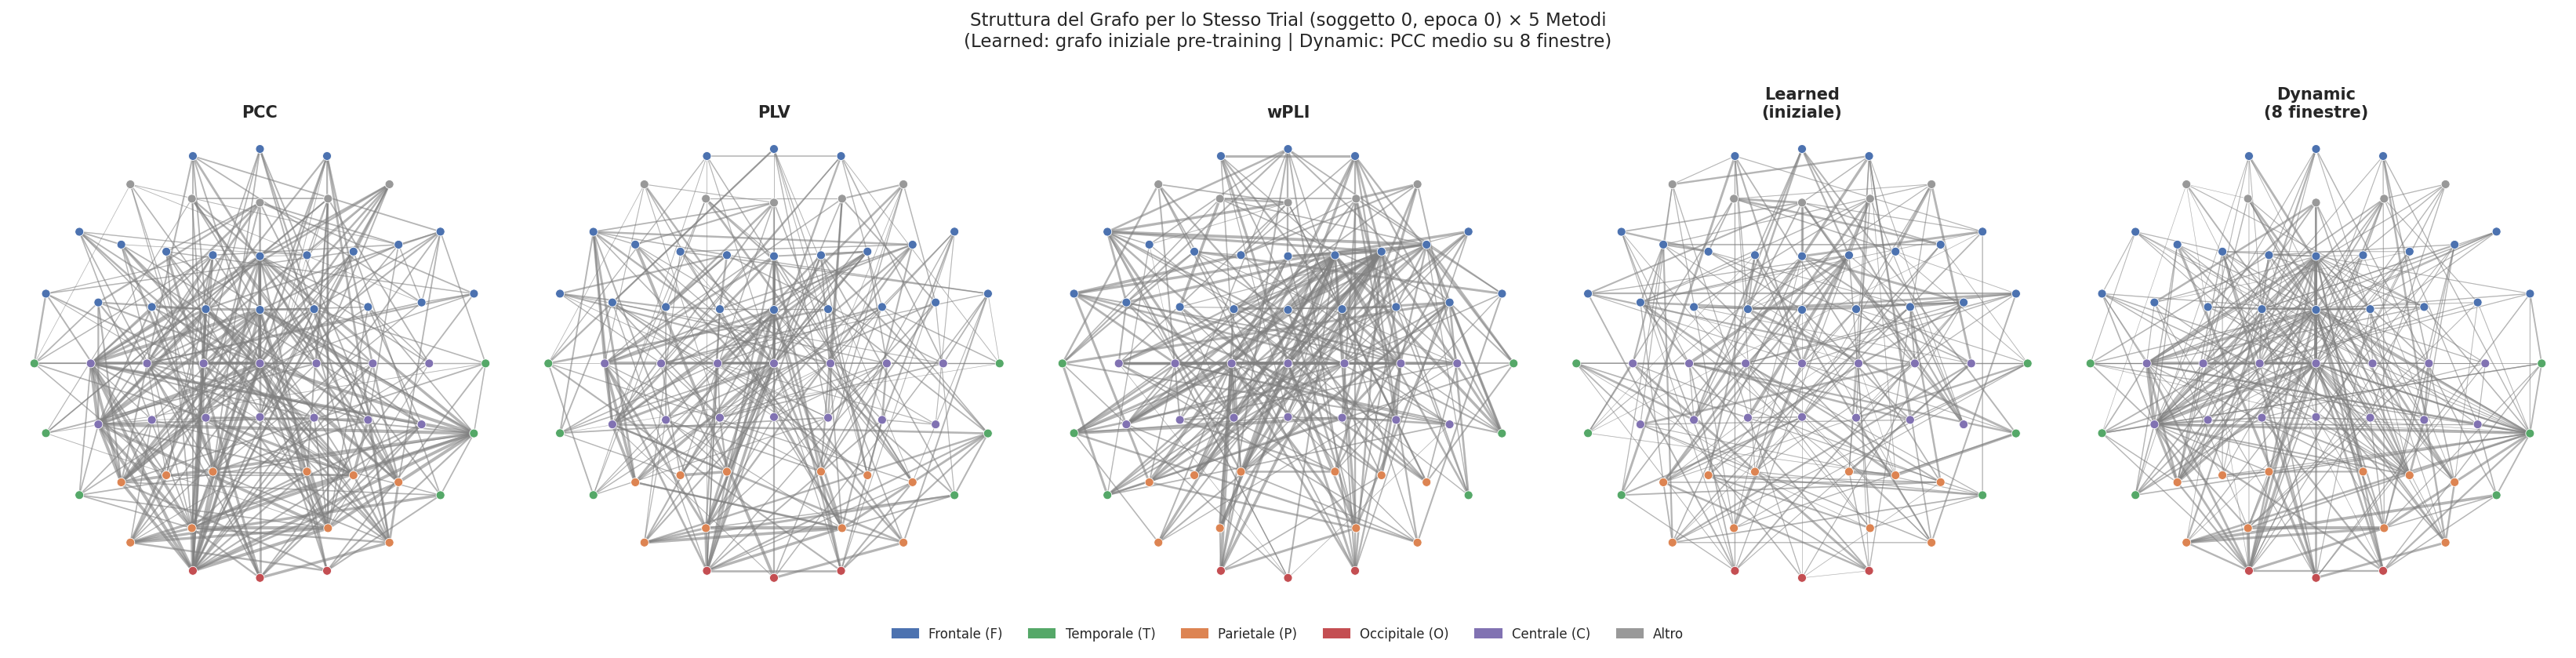


Salvato in: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg08_graph_comparison_trial0.png


In [26]:
import math
import h5py
from scipy.signal import butter, filtfilt
from scipy.signal import hilbert as sp_hilbert

# ── Funzioni helper ──────────────────────────────────────────────────

def read_eloc(path):
    """Legge posizioni elettrodi dal file .locs (formato EEGLAB)."""
    pos = {}
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 4:
                try:
                    theta  = float(parts[1])
                    radius = float(parts[2])
                    name   = parts[3]
                    th = math.radians(theta)
                    pos[name] = (radius * math.sin(th), radius * math.cos(th))
                except Exception:
                    pass
    return pos


def get_region_color(name):
    """Colore per regione cerebrale basato sul prefisso del nome elettrodo."""
    n = name.upper()
    if n.startswith("F"):
        return "#4C72B0"   # frontale — blu
    elif n.startswith("T"):
        return "#55A868"   # temporale — verde
    elif n.startswith("P"):
        return "#DD8452"   # parietale — arancio
    elif n.startswith("O"):
        return "#C44E52"   # occipitale — rosso
    elif n.startswith("C"):
        return "#8172B2"   # centrale — viola
    else:
        return "#999999"   # altro — grigio


def read_eloc_names(path):
    names = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 4:
                names.append(parts[3])
    return names[:61]


def knn_from_matrix(matrix, k):
    """Da matrice di connettività (NxN) → edge_index (2, E) come numpy."""
    edges = set()
    for i in range(matrix.shape[0]):
        for j in np.argsort(matrix[i])[::-1][:k]:
            if i != j:
                edges.add((i, int(j)))
                edges.add((int(j), i))
    src, dst = zip(*sorted(edges))
    return np.array([list(src), list(dst)], dtype=np.int64)


def pcc_matrix(x_np):
    """PCC assoluto tra canali. x_np: (n_chans, n_samples)."""
    pcc = np.abs(np.corrcoef(x_np))
    np.fill_diagonal(pcc, 0.0)
    return pcc


PLV_BANDS = [(4, 8), (8, 13)]
SFREQ = 256

def plv_matrix(x_np, sfreq=256, bands=None):
    if bands is None:
        bands = PLV_BANDS
    nyq = sfreq / 2.0
    plv_sum = np.zeros((x_np.shape[0], x_np.shape[0]), dtype=np.float64)
    for flo, fhi in bands:
        b, a = butter(4, [flo / nyq, fhi / nyq], btype="band")
        x_filt = filtfilt(b, a, x_np, axis=1).astype(np.float32)
        analytic = sp_hilbert(x_filt, axis=1)
        exp_phi = np.exp(1j * np.angle(analytic))
        plv_sum += np.abs(exp_phi @ exp_phi.conj().T) / x_np.shape[1]
    mat = (plv_sum / len(bands)).astype(np.float32)
    np.fill_diagonal(mat, 0.0)
    return mat


def wpli_matrix(x_np, sfreq=256, bands=None):
    if bands is None:
        bands = PLV_BANDS
    nyq = sfreq / 2.0
    wpli_sum = np.zeros((x_np.shape[0], x_np.shape[0]), dtype=np.float64)
    for flo, fhi in bands:
        b, a = butter(4, [flo / nyq, fhi / nyq], btype="band")
        x_filt = filtfilt(b, a, x_np, axis=1).astype(np.float32)
        analytic = sp_hilbert(x_filt, axis=1)
        imag_cs = np.imag(
            analytic[:, np.newaxis, :] * analytic[np.newaxis, :, :].conj()
        )
        wpli_sum += np.abs(imag_cs.mean(axis=-1)) / (np.abs(imag_cs).mean(axis=-1) + 1e-8)
    mat = (wpli_sum / len(bands)).astype(np.float32)
    np.fill_diagonal(mat, 0.0)
    return mat


def dynamic_pcc_matrix(x_np, n_windows=8):
    """Media PCC su n_windows finestre temporali."""
    n_chans, T = x_np.shape
    win_size = T // n_windows
    pcc_sum = np.zeros((n_chans, n_chans), dtype=np.float64)
    for w in range(n_windows):
        x_win = x_np[:, w * win_size:(w + 1) * win_size]
        pcc_sum += pcc_matrix(x_win)
    return (pcc_sum / n_windows).astype(np.float32)


def learned_initial_matrix(n_chans=59, seed=42):
    """Simula la matrice di adiacenza iniziale del modello Learned (pre-training)."""
    rng = np.random.RandomState(seed)
    A_raw = rng.randn(n_chans, n_chans) * 0.01
    # Rendi simmetrica e non-negativa (sigmoid)
    A = (A_raw + A_raw.T) / 2
    A = 1.0 / (1.0 + np.exp(-A))  # sigmoid
    np.fill_diagonal(A, 0.0)
    return A.astype(np.float32)


# ── Configurazione ───────────────────────────────────────────────────
K_GRAPH = 6
N_CHANS = 59

locs_path  = project_root / "src" / "io" / "ebneuro.locs"
graphs_dir = project_root / "data" / "interim" / "graphs"
meta_csv   = project_root / "data" / "interim" / "eeg_metadata.csv"

try:
    if not locs_path.exists():
        raise FileNotFoundError(f"File .locs non trovato: {locs_path}")

    # Leggi posizioni e nomi elettrodi
    eloc = read_eloc(locs_path)
    ch_names_61 = read_eloc_names(locs_path)
    EXCLUDE = {"A1", "A2"}
    keep_idx = [i for i, n in enumerate(ch_names_61) if n not in EXCLUDE]
    node_names = [ch_names_61[i] for i in keep_idx][:N_CHANS]

    # Coordinate 2D per il plot
    xs = np.array([eloc.get(n, (0, 0))[0] for n in node_names])
    ys = np.array([eloc.get(n, (0, 0))[1] for n in node_names])
    node_colors = [get_region_color(n) for n in node_names]

    # ── Carica dati grezzi del primo trial per Dynamic e come fallback ──
    meta = pd.read_csv(meta_csv)
    meta = meta[~(
        (meta["path_h5"].str.contains("08_05.h5") & (meta["epoch_idx"] >= 110)) |
        (meta["path_h5"].str.contains("46_01.h5") & (meta["epoch_idx"] >= 110)) |
        (meta["path_h5"].str.contains("46_03.h5") & (meta["epoch_idx"] >= 110)) |
        (meta["path_h5"].str.contains("46_04.h5") & (meta["epoch_idx"] >= 34))
    )].copy()
    meta = meta[pd.to_numeric(meta["subject_id"], errors="coerce").notna()].copy()

    first_trial = meta.iloc[0]
    h5_path = first_trial["path_h5"]
    epoch_idx = int(first_trial["epoch_idx"])

    with h5py.File(h5_path, "r") as f:
        x_raw = f["data"][epoch_idx][keep_idx, :].astype(np.float32)

    print(f"Dati raw caricati: soggetto {first_trial['subject_id']}, "
          f"sessione {first_trial['session_id']}, epoca {epoch_idx}")
    print(f"Shape: {x_raw.shape} ({N_CHANS} canali × {x_raw.shape[1]} campioni)")

    # ── Costruisci i 5 grafi ──────────────────────────────────────────
    # Dizionario: method → (edge_index, connectivity_matrix, label)
    graphs = {}

    # 1) PCC — dal dato grezzo (o da .pt se disponibile)
    pcc_mat = pcc_matrix(x_raw)
    graphs["PCC"] = {
        "edge_index": knn_from_matrix(pcc_mat, K_GRAPH),
        "conn_matrix": pcc_mat,
        "label": "PCC"
    }

    # 2) PLV — calcolato a mano
    plv_mat = plv_matrix(x_raw)
    graphs["PLV"] = {
        "edge_index": knn_from_matrix(plv_mat, K_GRAPH),
        "conn_matrix": plv_mat,
        "label": "PLV"
    }

    # 3) wPLI — calcolato a mano
    wpli_mat = wpli_matrix(x_raw)
    graphs["wPLI"] = {
        "edge_index": knn_from_matrix(wpli_mat, K_GRAPH),
        "conn_matrix": wpli_mat,
        "label": "wPLI"
    }

    # 4) Learned — matrice iniziale (pre-training)
    learned_mat = learned_initial_matrix(N_CHANS)
    graphs["Learned"] = {
        "edge_index": knn_from_matrix(learned_mat, K_GRAPH),
        "conn_matrix": learned_mat,
        "label": "Learned\n(iniziale)"
    }

    # 5) Dynamic — media PCC su 8 finestre
    dyn_mat = dynamic_pcc_matrix(x_raw, n_windows=8)
    graphs["Dynamic"] = {
        "edge_index": knn_from_matrix(dyn_mat, K_GRAPH),
        "conn_matrix": dyn_mat,
        "label": "Dynamic\n(8 finestre)"
    }

    print(f"\n{'Metodo':<15} {'Archi':<10} {'Archi unici':<15}")
    print("-" * 40)
    for method, g in graphs.items():
        n_edges = g["edge_index"].shape[1]
        n_unique = n_edges // 2
        print(f"{method:<15} {n_edges:<10} {n_unique:<15}")

    # ── Disegna i 5 grafi ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 5, figsize=(22, 5), dpi=150)
    fig.suptitle(
        "Struttura del Grafo per lo Stesso Trial (soggetto 0, epoca 0) × 5 Metodi\n"
        "(Learned: grafo iniziale pre-training | Dynamic: PCC medio su 8 finestre)",
        fontsize=11, y=1.05
    )

    methods_order = ["PCC", "PLV", "wPLI", "Learned", "Dynamic"]

    for ax, method in zip(axes, methods_order):
        g = graphs[method]
        ei = g["edge_index"]
        conn = g["conn_matrix"]

        ax.set_title(g["label"], fontsize=10, fontweight="bold")
        ax.set_aspect("equal")
        ax.axis("off")

        # Pesi archi normalizzati → spessore
        edge_weights = []
        for i in range(ei.shape[1]):
            src, dst = ei[0, i], ei[1, i]
            edge_weights.append(conn[src, dst])
        edge_weights = np.array(edge_weights)
        ew_min, ew_max = edge_weights.min(), edge_weights.max()
        if ew_max > ew_min:
            lws = 0.3 + 1.7 * (edge_weights - ew_min) / (ew_max - ew_min)
        else:
            lws = np.ones(len(edge_weights)) * 0.8

        # Disegna archi
        for i in range(ei.shape[1]):
            src, dst = ei[0, i], ei[1, i]
            ax.plot(
                [xs[src], xs[dst]], [ys[src], ys[dst]],
                color="gray", alpha=0.35, linewidth=float(lws[i]), zorder=1
            )

        # Disegna nodi
        ax.scatter(xs, ys, c=node_colors, s=28, zorder=5,
                   edgecolors="white", linewidths=0.4)

    # Legenda regioni
    region_legend = [
        mpatches.Patch(color="#4C72B0", label="Frontale (F)"),
        mpatches.Patch(color="#55A868", label="Temporale (T)"),
        mpatches.Patch(color="#DD8452", label="Parietale (P)"),
        mpatches.Patch(color="#C44E52", label="Occipitale (O)"),
        mpatches.Patch(color="#8172B2", label="Centrale (C)"),
        mpatches.Patch(color="#999999", label="Altro"),
    ]
    fig.legend(handles=region_legend, loc="lower center", ncol=6, fontsize=8,
               bbox_to_anchor=(0.5, -0.04))

    plt.tight_layout()
    out_path = figures_dir / "eeg08_graph_comparison_trial0.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nSalvato in: {out_path}")

except FileNotFoundError as e:
    print(f"[SKIP] {e}")
    print("Eseguire il notebook EEG_07b_precompute_graphs.ipynb sulla VM prima di rieseguire questa cella.")
except Exception as e:
    print(f"[ERRORE] {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()


## Plot 6 — Statistiche Comparative dei Grafi

Analisi quantitativa delle proprietà strutturali dei 5 grafi di connettività:

1. **Tabella riassuntiva**: nodi, archi unici, grado medio, densità, coefficiente di clustering medio
2. **Bar chart**: grado medio per metodo
3. **Heatmap della distribuzione dei gradi**: heatmap (metodo × grado)
4. **Overlap degli archi (Jaccard)**: quanto sono simili le topologie tra i diversi metodi

> Queste metriche aiutano a capire se i diversi metodi producono grafi strutturalmente diversi, o se convergono verso topologie simili.

STATISTICHE COMPARATIVE DEI GRAFI (stesso trial, soggetto 0, epoca 0)
 Metodo  Nodi  Archi Grado medio Grado std  Grado min  Grado max Densità Clustering medio  Componenti
    PCC    59    292         9.9      4.57          6         23  0.1707           0.4324           1
    PLV    59    242         8.2      2.55          6         16  0.1414           0.2875           1
   wPLI    59    244         8.3      3.37          6         24  0.1426           0.1673           1
Learned    59    217         7.4      1.52          6         12  0.1268           0.1152           1
Dynamic    59    294        10.0      6.63          6         35  0.1718           0.3861           1



/tmp/ipykernel_380196/3688629069.py:164: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(degree_data, labels=methods_order, patch_artist=True,


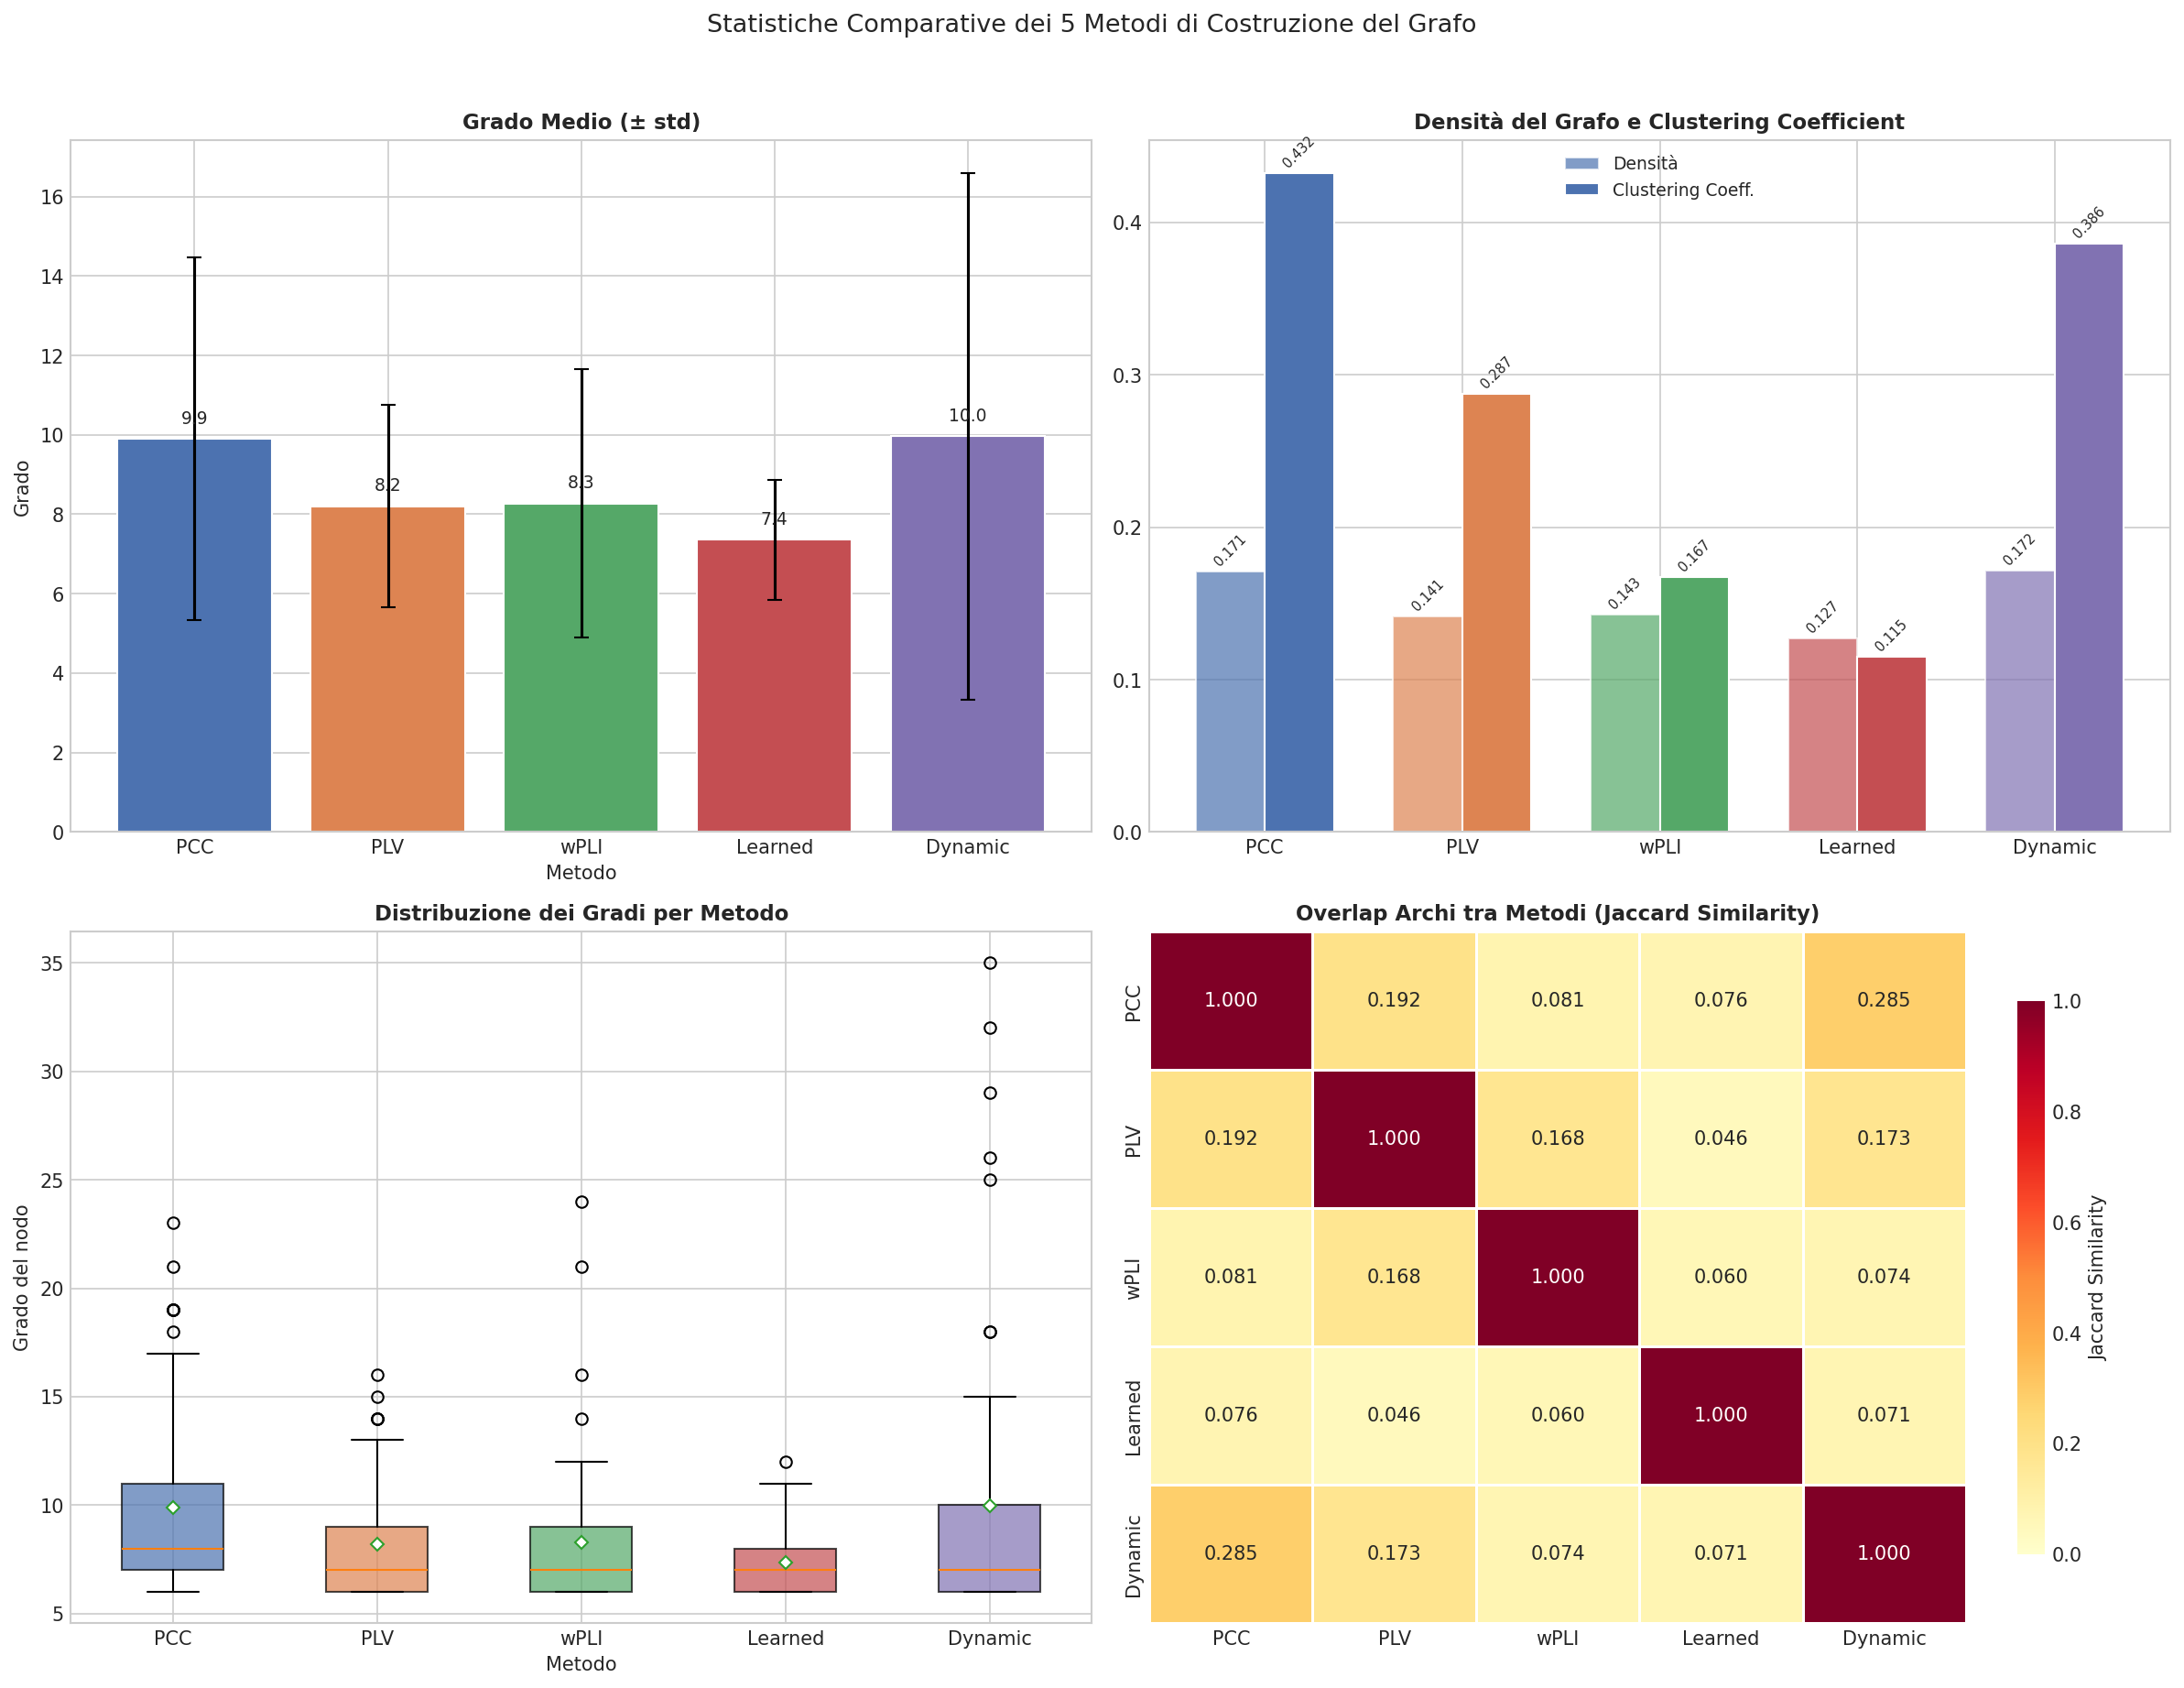


Salvato in: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg08_graph_statistics.png


In [27]:
# ── Plot 6: Statistiche Comparative dei Grafi ─────────────────────────

def compute_graph_stats(edge_index, n_nodes):
    """Calcola statistiche di un grafo da edge_index (2, E) numpy."""
    # Costruisci lista adiacenza (non-directed)
    adj = {i: set() for i in range(n_nodes)}
    for i in range(edge_index.shape[1]):
        src, dst = edge_index[0, i], edge_index[1, i]
        adj[src].add(dst)
        adj[dst].add(src)

    degrees = [len(adj[i]) for i in range(n_nodes)]
    n_edges_unique = sum(degrees) // 2

    # Densità
    max_edges = n_nodes * (n_nodes - 1) / 2
    density = n_edges_unique / max_edges if max_edges > 0 else 0

    # Clustering coefficient medio
    cc_list = []
    for v in range(n_nodes):
        neighbors = list(adj[v])
        k = len(neighbors)
        if k < 2:
            cc_list.append(0.0)
            continue
        links = 0
        for i in range(k):
            for j in range(i + 1, k):
                if neighbors[j] in adj[neighbors[i]]:
                    links += 1
        cc_list.append(2.0 * links / (k * (k - 1)))
    avg_cc = np.mean(cc_list)

    # Componenti connesse (BFS)
    visited = set()
    n_components = 0
    for start in range(n_nodes):
        if start in visited:
            continue
        n_components += 1
        queue = [start]
        while queue:
            node = queue.pop(0)
            if node in visited:
                continue
            visited.add(node)
            for nb in adj[node]:
                if nb not in visited:
                    queue.append(nb)

    return {
        "n_nodes": n_nodes,
        "n_edges": n_edges_unique,
        "mean_degree": np.mean(degrees),
        "std_degree": np.std(degrees),
        "min_degree": np.min(degrees),
        "max_degree": np.max(degrees),
        "density": density,
        "avg_clustering": avg_cc,
        "n_components": n_components,
        "degrees": degrees,
    }


def jaccard_edge_overlap(ei1, ei2):
    """Jaccard similarity tra due insiemi di archi (non-directed)."""
    def edge_set(ei):
        s = set()
        for i in range(ei.shape[1]):
            a, b = int(ei[0, i]), int(ei[1, i])
            s.add((min(a, b), max(a, b)))
        return s
    s1, s2 = edge_set(ei1), edge_set(ei2)
    intersection = len(s1 & s2)
    union = len(s1 | s2)
    return intersection / union if union > 0 else 0.0


try:
    if 'graphs' not in dir() or not graphs:
        raise RuntimeError("Eseguire prima la cella Plot 5 per costruire i grafi.")

    methods_order = ["PCC", "PLV", "wPLI", "Learned", "Dynamic"]

    # ── Calcola statistiche ──────────────────────────────────────────
    stats = {}
    for method in methods_order:
        stats[method] = compute_graph_stats(graphs[method]["edge_index"], N_CHANS)

    # ── Tabella Riassuntiva ──────────────────────────────────────────
    stats_df = pd.DataFrame([
        {
            "Metodo": method,
            "Nodi": stats[method]["n_nodes"],
            "Archi": stats[method]["n_edges"],
            "Grado medio": f"{stats[method]['mean_degree']:.1f}",
            "Grado std": f"{stats[method]['std_degree']:.2f}",
            "Grado min": stats[method]["min_degree"],
            "Grado max": stats[method]["max_degree"],
            "Densità": f"{stats[method]['density']:.4f}",
            "Clustering medio": f"{stats[method]['avg_clustering']:.4f}",
            "Componenti": stats[method]["n_components"],
        }
        for method in methods_order
    ])
    print("=" * 80)
    print("STATISTICHE COMPARATIVE DEI GRAFI (stesso trial, soggetto 0, epoca 0)")
    print("=" * 80)
    print(stats_df.to_string(index=False))
    print()

    # ── Figure: 2×2 subplot ──────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=150)
    fig.suptitle("Statistiche Comparative dei 5 Metodi di Costruzione del Grafo",
                 fontsize=13, y=1.02)

    METHOD_COLORS = {
        "PCC":     "#4C72B0",
        "PLV":     "#DD8452",
        "wPLI":    "#55A868",
        "Learned": "#C44E52",
        "Dynamic": "#8172B2",
    }
    colors = [METHOD_COLORS[m] for m in methods_order]

    # ── Subplot 1: Grado Medio ───────────────────────────────────────
    ax1 = axes[0, 0]
    mean_degs = [stats[m]["mean_degree"] for m in methods_order]
    std_degs  = [stats[m]["std_degree"] for m in methods_order]
    bars = ax1.bar(methods_order, mean_degs, color=colors, edgecolor="white",
                   yerr=std_degs, capsize=4)
    for bar, val in zip(bars, mean_degs):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=9)
    ax1.set_title("Grado Medio (± std)", fontsize=11, fontweight="bold")
    ax1.set_ylabel("Grado")
    ax1.set_xlabel("Metodo")

    # ── Subplot 2: Densità e Clustering ──────────────────────────────
    ax2 = axes[0, 1]
    x_pos = np.arange(len(methods_order))
    width = 0.35
    densities = [stats[m]["density"] for m in methods_order]
    clusterings = [stats[m]["avg_clustering"] for m in methods_order]
    bars1 = ax2.bar(x_pos - width/2, densities, width, color=colors, alpha=0.7,
                    edgecolor="white", label="Densità")
    bars2 = ax2.bar(x_pos + width/2, clusterings, width, color=colors,
                    edgecolor="white", label="Clustering Coeff.")
    for bar, val in zip(bars1, densities):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=7, rotation=45)
    for bar, val in zip(bars2, clusterings):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=7, rotation=45)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(methods_order)
    ax2.set_title("Densità del Grafo e Clustering Coefficient", fontsize=11, fontweight="bold")
    ax2.legend(fontsize=9)

    # ── Subplot 3: Distribuzione dei Gradi (boxplot) ─────────────────
    ax3 = axes[1, 0]
    degree_data = [stats[m]["degrees"] for m in methods_order]
    bp = ax3.boxplot(degree_data, labels=methods_order, patch_artist=True,
                     showmeans=True, meanprops=dict(marker='D', markerfacecolor='white', markersize=5))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax3.set_title("Distribuzione dei Gradi per Metodo", fontsize=11, fontweight="bold")
    ax3.set_ylabel("Grado del nodo")
    ax3.set_xlabel("Metodo")

    # ── Subplot 4: Jaccard Edge Overlap ──────────────────────────────
    ax4 = axes[1, 1]
    n_methods = len(methods_order)
    jaccard_matrix = np.zeros((n_methods, n_methods))
    for i, m1 in enumerate(methods_order):
        for j, m2 in enumerate(methods_order):
            if i == j:
                jaccard_matrix[i, j] = 1.0
            else:
                jaccard_matrix[i, j] = jaccard_edge_overlap(
                    graphs[m1]["edge_index"], graphs[m2]["edge_index"]
                )
    sns.heatmap(
        jaccard_matrix, ax=ax4,
        xticklabels=methods_order, yticklabels=methods_order,
        annot=True, fmt=".3f", cmap="YlOrRd",
        vmin=0, vmax=1, linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Jaccard Similarity", "shrink": 0.8},
        annot_kws={"size": 10},
    )
    ax4.set_title("Overlap Archi tra Metodi (Jaccard Similarity)", fontsize=11, fontweight="bold")

    plt.tight_layout()
    out_path = figures_dir / "eeg08_graph_statistics.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nSalvato in: {out_path}")

except Exception as e:
    print(f"[ERRORE] {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()


## Conclusioni

### Riepilogo Risultati EEG_08

| Metodo | Architettura | val_bacc | test_bacc | Tempo (min) |
|--------|-------------|----------|-----------|-------------|
| PCC    | ChebGCN_2L      | 0.2527 | 0.2490 | 2.4  |
| PCC    | ChebGCN_3L      | 0.2607 | 0.2445 | 5.1  |
| PCC    | ChebGCN_Skip    | 0.2538 | 0.2524 | 3.2  |
| PLV    | ChebGCN_2L      | 0.2557 | 0.2437 | 3.4  |
| PLV    | ChebGCN_3L      | 0.2522 | 0.2469 | 3.3  |
| PLV    | ChebGCN_Skip    | 0.2503 | 0.2499 | 3.8  |
| wPLI   | ChebGCN_2L      | 0.2511 | 0.2514 | 2.9  |
| wPLI   | ChebGCN_3L      | 0.2528 | 0.2512 | 3.7  |
| wPLI   | ChebGCN_Skip    | 0.2535 | 0.2515 | 2.7  |
| Learned | ChebGCN_Learned | 0.2528 | 0.2430 | 103.7 |
| Dynamic | ChebGCN_Dynamic | 0.2501 | 0.2485 | 123.5 |

### Conclusioni Principali

1. **Tutti i modelli si attestano a chance level** (val_bacc ≈ 0.25): nessun metodo di costruzione del grafo porta a un apprendimento genuino della distinzione semantica.

2. **Class collapse pervasivo**: `val_acc` elevata (fino a 40%) è un artefatto — i modelli predicono la classe maggioritaria. La `val_bacc` è la metrica corretta da monitorare.

3. **Il metodo del grafo non fa differenza**: PCC, PLV, wPLI, Learned e Dynamic producono performance equivalenti in termini di `val_bacc`. Non c'è guadagno nell'usare grafi più complessi.

4. **Trade-off tempo/accuratezza**: Learned (~104 min) e Dynamic (~124 min) sono **~50× più lenti** di PCC/PLV/wPLI (2-5 min) senza alcun vantaggio. Scartarli per i prossimi esperimenti.

5. **Best baseline**: PCC / ChebGCN_3L con val_bacc=0.2607 è il migliore in assoluto, ma il margine sul chance è minimo e probabilmente non significativo.

### Prossimi Passi

- Passare a **EEGNet / EEG Conformer** su segnale raw (EEG_09): architetture end-to-end progettate specificamente per EEG
- Aggiungere **class weights** per contrastare il class collapse
- Esplorare **domain adaptation** cross-soggetto (la variabilità inter-soggetto, ε²=0.85, è il principale ostacolo)